# Decision Trees

----

In [6]:
# Import libraries
import numpy as np
import pandas as pd

import pickle

import matplotlib.pyplot as plt

from sklearn.tree import export_text, plot_tree, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, confusion_matrix, balanced_accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import PartialDependenceDisplay

## Prepare data

In [7]:
df = pd.read_csv("../data/GamingStudy_data_clean.csv")
df.head()

,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,streams,SPIN1,SPIN2,SPIN3,...,Work_Unknown,Degree_High school diploma (or equivalent),Degree_Master (or equivalent),"Degree_Ph.D., Psy. D., MD (or equivalent)",Degree_Unknown,Playstyle_Offline Multiplayer,Playstyle_Other,Playstyle_Real Life Friends,Playstyle_Singleplayer,Playstyle_Strangers
0,7,7,7,5,7,25.0,2.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,6,6,6,3,5,5.0,5.0,2.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,1
2,5,2,6,7,6,9.0,2.0,2.0,2.0,2.0,...,0,1,0,0,0,0,0,1,0,0
3,2,4,6,6,3,7.0,4.0,0.0,1.0,3.0,...,0,0,1,0,0,0,0,0,0,1
4,2,2,1,3,2,25.0,35.0,0.0,2.0,1.0,...,0,1,0,0,0,0,0,0,0,1


In [8]:
df.shape

(10772, 60)

In [9]:
with open("../data/data.pkl", "rb") as f:
    data = pickle.load(f)

print(data.keys())

dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'FEATURES'])


In [10]:
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
FEATURES = data["FEATURES"]

In [27]:
print(FEATURES.keys())

dict_keys(['A_psych', 'B_gaming', 'C_full'])


In [28]:
print(FEATURES["A_psych"])
print(FEATURES["B_gaming"])
print(FEATURES["C_full"])

['SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17', 'SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5', 'Age', 'Gender_Male', 'Gender_Other', 'Work_Student at college / university', 'Work_Student at school', 'Work_Unemployed / between jobs', 'Work_Unknown', 'Degree_High school diploma (or equivalent)', 'Degree_Master\xa0(or equivalent)', 'Degree_Ph.D., Psy. D., MD (or equivalent)', 'Degree_Unknown']
['Hours', 'streams', 'Platform_PC', 'Platform_Smartphone / Tablet', 'earnings_Other', 'earnings_Professional', 'earnings_Side Income', 'whyplay_Improving', 'whyplay_Other', 'whyplay_Relaxing', 'whyplay_Winning', 'League_Challenger', 'League_Diamond', 'League_Gold', 'League_Master', 'League_Other', 'League_Platinum', 'League_Silver', 'League_Unknown', 'League_Unranked', 'Playstyle_Offline Multiplayer', 'Playstyle_Other', 'Playstyle_Real Life Friends', 'Playstyle_Singleplayer', 'Playstyle_Strange

In [11]:
X_train.head()

,SPIN2,SPIN13,SWL5,League_Unknown,Playstyle_Other,League_Other,League_Diamond,Playstyle_Singleplayer,SWL1,Work_Student at college / university,...,Narcissism,SPIN15,SWL3,whyplay_Improving,"Degree_Ph.D., Psy. D., MD (or equivalent)",SPIN11,Playstyle_Strangers,Platform_PC,League_Challenger,SWL2
10657,2.0,0.0,3,0,0,0,1,0,5,1,...,1.0,1.0,5,1,0,0.0,0,1,0,5
4174,3.0,3.0,1,0,0,0,0,0,1,1,...,4.0,4.0,2,1,0,4.0,1,1,0,1
1965,2.0,3.0,5,0,0,0,0,0,3,1,...,2.0,4.0,5,0,0,3.0,0,1,0,5
518,1.0,1.0,6,0,0,0,0,0,6,0,...,3.0,3.0,6,1,0,4.0,0,1,0,5
805,2.0,0.0,1,0,0,0,1,0,3,1,...,1.0,3.0,5,1,0,0.0,0,1,0,2


In [12]:
y_train.head()

10657    0
4174     1
1965     0
518      0
805      1
Name: GAD_T, dtype: int64

In [13]:
print(y_train.unique())
print(y_train.describe())

[0 1]
count    8536.000000
mean        0.171392
std         0.376873
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: GAD_T, dtype: float64


In [14]:
print(X_train.describe())

             SPIN2       SPIN13         SWL5  League_Unknown  Playstyle_Other  \
count  8536.000000  8536.000000  8536.000000     8536.000000      8536.000000   
mean      1.214738     0.537137     3.357896        0.106959         0.007849   
std       1.146012     0.941040     1.912792        0.309079         0.088252   
min       0.000000     0.000000     1.000000        0.000000         0.000000   
25%       0.000000     0.000000     2.000000        0.000000         0.000000   
50%       1.000000     0.000000     3.000000        0.000000         0.000000   
75%       2.000000     1.000000     5.000000        0.000000         0.000000   
max       4.000000     4.000000     7.000000        1.000000         1.000000   

       League_Other  League_Diamond  Playstyle_Singleplayer         SWL1  \
count   8536.000000     8536.000000             8536.000000  8536.000000   
mean       0.026710        0.121251                0.035965     3.734185   
std        0.161245        0.326438       

In [29]:
X_train_psych = X_train[FEATURES["A_psych"]]
X_test_psych  = X_test[FEATURES["A_psych"]]

X_train_gaming = X_train[FEATURES["B_gaming"]]
X_test_gaming  = X_test[FEATURES["B_gaming"]]

X_train_full = X_train[FEATURES["C_full"]]
X_test_full  = X_test[FEATURES["C_full"]]

## Modeling

### Decision Tree - Psych Questionnaire Features Only

In [53]:
# fit decision tree model
tree_gaming_psych = DecisionTreeClassifier(random_state = 1)
tree_gaming_psych.fit(X_train_psych, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [54]:
tree_summary = export_text(tree_gaming_psych, feature_names=X_train_psych.columns.tolist())
print(tree_summary)

|--- SWL3 <= 2.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN15 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- SPIN3 <= 2.50
|   |   |   |   |   |--- SPIN2 <= 3.50
|   |   |   |   |   |   |--- SWL2 <= 2.50
|   |   |   |   |   |   |   |--- SPIN16 <= 1.50
|   |   |   |   |   |   |   |   |--- SPIN7 <= 2.50
|   |   |   |   |   |   |   |   |   |--- SPIN4 <= 3.50
|   |   |   |   |   |   |   |   |   |   |--- SWL5 <= 3.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |   |   |   |   |   |   |--- SWL5 >  3.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- SPIN4 >  3.50
|   |   |   |   |   |   |   |   |   |   |--- SPIN5 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |   |--- SPIN5 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- SPIN7 >  2.50
|   |   |   |   |  

In [55]:
importances = pd.DataFrame({'feature_name': X_train_psych.columns, 'importance': tree_gaming_psych.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

                                  feature_name  importance
0                                         SWL3    0.114680
1                                         SWL2    0.058252
2                                          Age    0.057209
3                                       SPIN13    0.055311
4                                       SPIN14    0.052473
5                                         SWL1    0.042159
6                                        SPIN5    0.040177
7                                       SPIN15    0.039997
8                                       SPIN16    0.039674
9                                        SPIN6    0.038118
10                                       SPIN4    0.037504
11                                       SPIN2    0.037320
12                                       SPIN7    0.037163
13                                        SWL4    0.036544
14                                      SPIN17    0.035422
15                                      SPIN11    0.0347

<span style="color:green"> From the importance table, SWL3 and SPIN13 appear to be the most important predictors. We can also see them at the top of the tree summary. </span>

In [56]:
# Calculate the accuracy of the decision tree on the test data
accuracy = tree_gaming_psych.score(X_test_psych, y_test)
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: 77.00%


<span style="color:green"> Accuracy score is 77.80% which means this model is decently accurate. </span>

### Tune Decision Tree

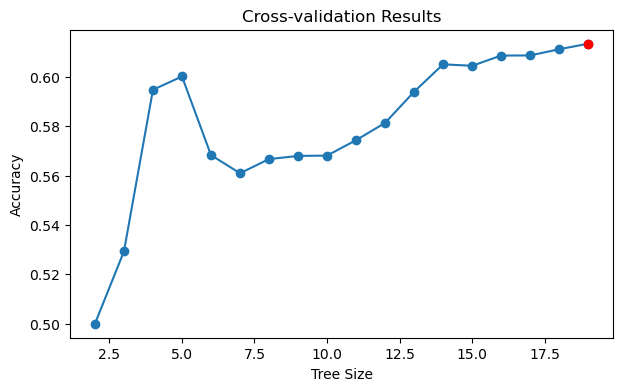

In [57]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_gaming_anxiety = GridSearchCV(tree_gaming_psych, params, cv=20, scoring="balanced_accuracy")
cv_gaming_anxiety.fit(X_train_psych, y_train)
cv_results = cv_gaming_anxiety.cv_results_

# find the best score for max leaf nodes
best_size = cv_gaming_anxiety.best_params_['max_leaf_nodes']
best_score = cv_gaming_anxiety.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [58]:
# fit pruned decision tree model
pruned_tree_gaming_psych = DecisionTreeClassifier(max_leaf_nodes=best_size, random_state=1)
pruned_tree_gaming_psych.fit(X_train_psych, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",19
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [59]:
pruned_tree_summary_psych = export_text(pruned_tree_gaming_psych, feature_names=X_train_psych.columns.tolist())
print(pruned_tree_summary_psych)

|--- SWL3 <= 2.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN15 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- class: 0
|   |   |--- SPIN15 >  3.50
|   |   |   |--- class: 1
|   |--- SPIN13 >  0.50
|   |   |--- SPIN6 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- class: 0
|   |   |--- SPIN6 >  3.50
|   |   |   |--- SPIN16 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- SPIN16 >  1.50
|   |   |   |   |--- class: 1
|--- SWL3 >  2.50
|   |--- SPIN14 <= 2.50
|   |   |--- SWL3 <= 4.50
|   |   |   |--- SPIN13 <= 0.50
|   |   |   |   |--- SPIN5 <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SPIN5 >  3.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- SPIN13 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- SWL3 >  4.50
|   |   |   |--- SPIN5 <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- SPIN5 >  2.50
|   |   |   |   

In [60]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned = pruned_tree_gaming_psych.score(X_test_psych, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned*100))

Accuracy: 83.28%


In [61]:
y_dt_pred = pruned_tree_gaming_psych.predict(X_test_psych)

In [62]:
print(confusion_matrix(y_test, y_dt_pred))

[[1687   82]
 [ 275   91]]


<span style="color:green"> 1687 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 82 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 275 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 91 people who have anxiety were correctly identified. </span>

In [63]:
print(classification_report(y_test, y_dt_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_dt_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1769
           1       0.53      0.25      0.34       366

    accuracy                           0.83      2135
   macro avg       0.69      0.60      0.62      2135
weighted avg       0.80      0.83      0.81      2135

Balanced Accuracy: 0.6011400037686075


<span style="color:green"> Recall of .25 means that the model only catches 25% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.53 means that when the model predicts anxiety, it's correct about 53% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 60% means that the model is better than random guessing which would be about 50% </span>

### Decision Tree - Gaming Features Only

In [65]:
# fit decision tree model
tree_gaming_gaming = DecisionTreeClassifier(random_state = 1)
tree_gaming_gaming.fit(X_train_gaming, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

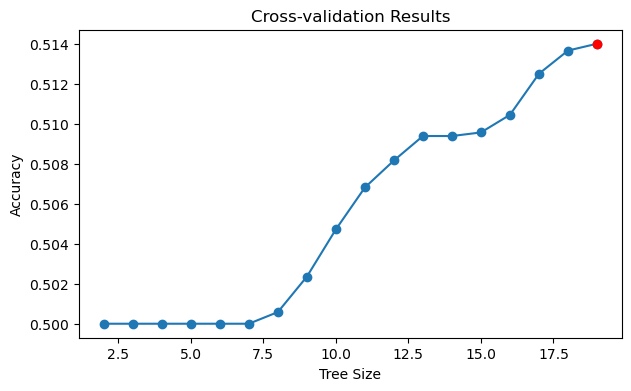

In [66]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_gaming_gaming = GridSearchCV(tree_gaming_gaming, params, cv=20, scoring="balanced_accuracy")
cv_gaming_gaming.fit(X_train_gaming, y_train)
cv_results = cv_gaming_gaming.cv_results_

# find the best score for max leaf nodes
best_size = cv_gaming_gaming.best_params_['max_leaf_nodes']
best_score = cv_gaming_gaming.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [67]:
# fit pruned decision tree model
pruned_tree_gaming = DecisionTreeClassifier(max_leaf_nodes=best_size, random_state=1)
pruned_tree_gaming.fit(X_train_gaming, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",19
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [68]:
pruned_tree_summary = export_text(pruned_tree_gaming, feature_names=X_train_gaming.columns.tolist())
print(pruned_tree_summary)

|--- Gender_Male <= 0.50
|   |--- Age <= 23.50
|   |   |--- whyplay_Winning <= 0.50
|   |   |   |--- class: 0
|   |   |--- whyplay_Winning >  0.50
|   |   |   |--- class: 1
|   |--- Age >  23.50
|   |   |--- class: 0
|--- Gender_Male >  0.50
|   |--- Hours <= 34.50
|   |   |--- whyplay_Winning <= 0.50
|   |   |   |--- whyplay_Relaxing <= 0.50
|   |   |   |   |--- streams <= 9.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- streams >  9.50
|   |   |   |   |   |--- Work_Unemployed / between jobs <= 0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Work_Unemployed / between jobs >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- whyplay_Relaxing >  0.50
|   |   |   |   |--- class: 0
|   |   |--- whyplay_Winning >  0.50
|   |   |   |--- streams <= 14.50
|   |   |   |   |--- earnings_Other <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- earnings_Other >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- streams >  14.50
|   |   | 

In [69]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned = pruned_tree_gaming.score(X_test_gaming, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned*100))

Accuracy: 82.48%


In [70]:
y_dt_pred_gaming = pruned_tree_gaming.predict(X_test_gaming)

In [71]:
print(confusion_matrix(y_test, y_dt_pred_gaming))

[[1748   21]
 [ 353   13]]


<span style="color:green"> 1748 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 21 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 353 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 13 people who have anxiety were correctly identified. </span>

In [51]:
print(classification_report(y_test, y_dt_pred_gaming))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_dt_pred_gaming))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1769
           1       0.38      0.04      0.07       366

    accuracy                           0.82      2135
   macro avg       0.61      0.51      0.48      2135
weighted avg       0.75      0.82      0.76      2135

Balanced Accuracy: 0.511824006029772


<span style="color:green"> Recall of .04 means that the model only catches 4% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.38 means that when the model predicts anxiety, it's only correct about 38% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 51% means that the model is not much better than random guessing which would be about 50% </span>

### Decision Tree - Full Feature Set

In [76]:
# fit decision tree model
tree_gaming_full = DecisionTreeClassifier(random_state = 1)
tree_gaming_full.fit(X_train_full, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

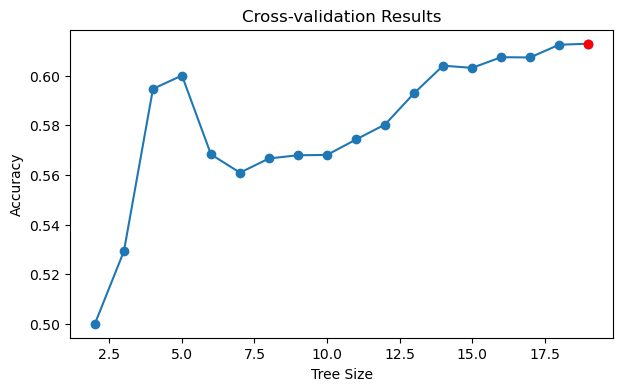

In [77]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_gaming_full = GridSearchCV(tree_gaming_full, params, cv=20, scoring="balanced_accuracy")
cv_gaming_full.fit(X_train_full, y_train)
cv_results = cv_gaming_full.cv_results_

# find the best score for max leaf nodes
best_size = cv_gaming_full.best_params_['max_leaf_nodes']
best_score = cv_gaming_full.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [78]:
# fit pruned decision tree model
pruned_tree_gaming_full = DecisionTreeClassifier(max_leaf_nodes=best_size, random_state=1)
pruned_tree_gaming_full.fit(X_train_full, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",19
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [79]:
pruned_tree_summary_full = export_text(pruned_tree_gaming_full, feature_names=X_train_full.columns.tolist())
print(pruned_tree_summary_full)

|--- SWL3 <= 2.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN15 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- class: 0
|   |   |--- SPIN15 >  3.50
|   |   |   |--- streams <= 7.00
|   |   |   |   |--- class: 0
|   |   |   |--- streams >  7.00
|   |   |   |   |--- class: 1
|   |--- SPIN13 >  0.50
|   |   |--- SPIN6 <= 3.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- class: 0
|   |   |--- SPIN6 >  3.50
|   |   |   |--- SPIN16 <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- SPIN16 >  1.50
|   |   |   |   |--- class: 1
|--- SWL3 >  2.50
|   |--- SPIN14 <= 2.50
|   |   |--- SWL3 <= 4.50
|   |   |   |--- SPIN13 <= 0.50
|   |   |   |   |--- SPIN5 <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SPIN5 >  3.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- SPIN13 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- SWL3 >  4.50
|   |   

In [80]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned = pruned_tree_gaming_full.score(X_test_full, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned*100))

Accuracy: 83.65%


In [81]:
y_dt_pred_gaming_full = pruned_tree_gaming_full.predict(X_test_full)

In [82]:
print(confusion_matrix(y_test, y_dt_pred_gaming_full))

[[1699   70]
 [ 279   87]]


<span style="color:green"> 1699 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 70 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 279 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 87 people who have anxiety were correctly identified. </span>

In [83]:
print(classification_report(y_test, y_dt_pred_gaming_full))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_dt_pred_gaming_full))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1769
           1       0.55      0.24      0.33       366

    accuracy                           0.84      2135
   macro avg       0.71      0.60      0.62      2135
weighted avg       0.81      0.84      0.81      2135

Balanced Accuracy: 0.5990672696438666


<span style="color:green"> Recall of .24 means that the model only catches 24% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.55 means that when the model predicts anxiety, it's only correct about 55% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 60% means that the model is better than random guessing which would be about 50% </span>

### Random Forest - Psych Questionnaire Features Only

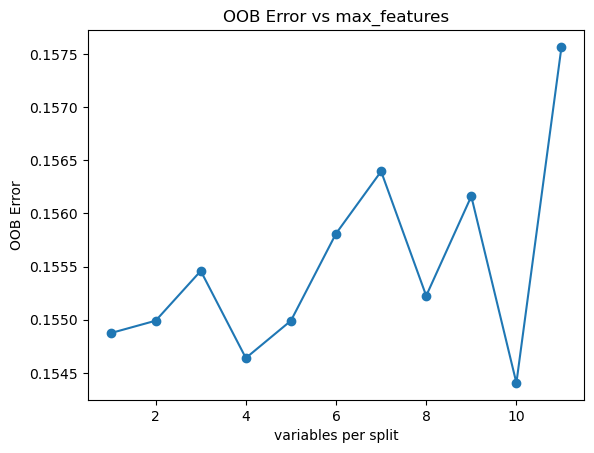

In [88]:
# Create plot to find optimal max_features
rf_gaming_psych = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_gaming_psych.set_params(max_features=n)
    
    rf_gaming_psych.fit(X_train_psych, y_train)
    oob_error = 1 - rf_gaming_psych.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()

In [90]:
# Fit random forest model
rf_gaming_psych = RandomForestClassifier(n_estimators=300, class_weight="balanced", max_features=4, random_state=1)
rf_gaming_psych.fit(X_train_psych, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [91]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned_psych = rf_gaming_psych.score(X_test_psych, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned_psych*100))

Accuracy: 84.36%


In [111]:
y_rf_pred_gaming_psych = rf_gaming_psych.predict(X_test_psych)

In [112]:
print(confusion_matrix(y_test, y_rf_pred_gaming_psych))

[[1747   22]
 [ 312   54]]


<span style="color:green"> 1747 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 22 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 312 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 54 people who have anxiety were correctly identified. </span>

In [113]:
print(classification_report(y_test, y_rf_pred_gaming_psych))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_rf_pred_gaming_psych))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91      1769
           1       0.71      0.15      0.24       366

    accuracy                           0.84      2135
   macro avg       0.78      0.57      0.58      2135
weighted avg       0.82      0.84      0.80      2135

Balanced Accuracy: 0.567552289429056


<span style="color:green"> Recall of .15 means that the model only catches 15% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.71 means that when the model predicts anxiety, it's correct about 71% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 56% means that the model is only slightly better than random guessing which would be about 50% </span>

### Random Forest - Gaming Features Only

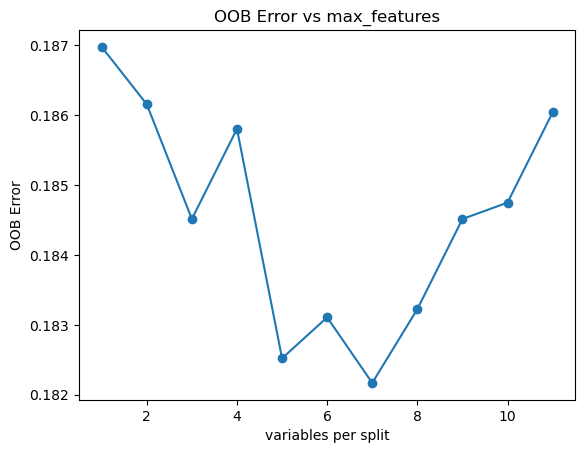

In [95]:
# Create plot to find optimal max_features
rf_gaming_gaming = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_gaming_gaming.set_params(max_features=n)
    
    rf_gaming_gaming.fit(X_train_gaming, y_train)
    oob_error = 1 - rf_gaming_gaming.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()

In [96]:
# Fit random forest model
rf_gaming_gaming = RandomForestClassifier(n_estimators=300, class_weight="balanced", max_features=5, random_state=1)
rf_gaming_gaming.fit(X_train_gaming, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [97]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned_gaming = rf_gaming_gaming.score(X_test_gaming, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned_gaming*100))

Accuracy: 81.97%


In [108]:
y_rf_pred_gaming = rf_gaming_gaming.predict(X_test_gaming)

In [109]:
print(confusion_matrix(y_test, y_rf_pred_gaming))

[[1738   31]
 [ 354   12]]


<span style="color:green"> 1738 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 31 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 354 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 12 people who have anxiety were correctly identified. </span>

In [110]:
print(classification_report(y_test, y_rf_pred_gaming))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_rf_pred_gaming))

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      1769
           1       0.28      0.03      0.06       366

    accuracy                           0.82      2135
   macro avg       0.55      0.51      0.48      2135
weighted avg       0.74      0.82      0.76      2135

Balanced Accuracy: 0.5076314301865461


<span style="color:green"> Recall of .03 means that the model only catches 3% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.28 means that when the model predicts anxiety, it's only correct about 28% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 50% means that the model is the same as random guessing which would also be about 50% </span>

### Random Forest - Full Feature Set

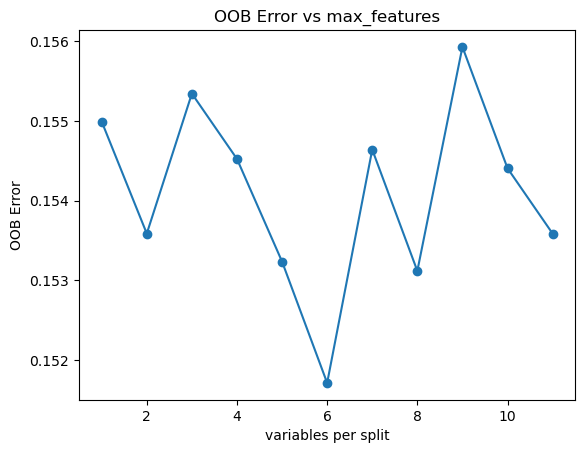

In [101]:
# Create plot to find optimal max_features
rf_gaming_full = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_gaming_full.set_params(max_features=n)
    
    rf_gaming_full.fit(X_train_full, y_train)
    oob_error = 1 - rf_gaming_full.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()

In [102]:
# Fit random forest model
rf_gaming_full = RandomForestClassifier(n_estimators=300, class_weight="balanced", max_features=6, random_state=1)
rf_gaming_full.fit(X_train_full, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [103]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned_full = rf_gaming_full.score(X_test_full, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned_full*100))

Accuracy: 84.36%


In [114]:
y_rf_pred_full = rf_gaming_full.predict(X_test_full)

In [115]:
print(confusion_matrix(y_test, y_rf_pred_full))

[[1748   21]
 [ 313   53]]


<span style="color:green"> 1748 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 21 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 313 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 53 people who have anxiety were correctly identified. </span>

In [116]:
print(classification_report(y_test, y_rf_pred_full))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_rf_pred_full))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91      1769
           1       0.72      0.14      0.24       366

    accuracy                           0.84      2135
   macro avg       0.78      0.57      0.58      2135
weighted avg       0.83      0.84      0.80      2135

Balanced Accuracy: 0.5664688147729414


<span style="color:green"> Recall of .14 means that the model only catches 14% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.72 means that when the model predicts anxiety, it's correct about 72% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 57% means that the model is barely better than random guessing which would also be about 50% </span>

### Boosting Model - Psych Questionnaire Features Only

In [118]:
boost = GradientBoostingClassifier(random_state=1)

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [1, 2, 3],
}

grid_boost = GridSearchCV(
    boost,
    param_grid,
    cv=5,
    scoring="balanced_accuracy"
)

grid_boost.fit(X_train_psych, y_train)

print(grid_boost.best_params_)
print(grid_boost.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
0.6336783455463639


In [123]:
# Fit Gradient Boosting model
boost_psych = GradientBoostingClassifier(**grid_boost.best_params_, random_state=1)
boost_psych.fit(X_train_psych, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [125]:
y_pred_boost_psych = boost_psych.predict(X_test_psych)

In [126]:
print(confusion_matrix(y_test, y_pred_boost_psych))

[[1695   74]
 [ 267   99]]


<span style="color:green"> 1695 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 74 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 267 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 99 people who have anxiety were correctly identified. </span>

In [127]:
print(classification_report(y_test, y_pred_boost_psych))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_boost_psych))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1769
           1       0.57      0.27      0.37       366

    accuracy                           0.84      2135
   macro avg       0.72      0.61      0.64      2135
weighted avg       0.81      0.84      0.82      2135

Balanced Accuracy: 0.6143301300169588


<span style="color:green"> Recall of .27 means that the model only catches 27% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.57 means that when the model predicts anxiety, it's correct about 57% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 61% means that the model is a little better than random guessing which would also be about 50% </span>

### Boosting Model - Gaming Features Only

In [128]:
boost_gaming = GradientBoostingClassifier(random_state=1)

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [1, 2, 3],
}

grid_boost_gaming = GridSearchCV(
    boost_gaming,
    param_grid,
    cv=5,
    scoring="balanced_accuracy"
)

grid_boost_gaming.fit(X_train_gaming, y_train)

print(grid_boost_gaming.best_params_)
print(grid_boost_gaming.best_score_)

{'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 500}
0.5314873212580145


In [129]:
# Fit Gradient Boosting model
boost_gaming = GradientBoostingClassifier(**grid_boost_gaming.best_params_, random_state=1)
boost_gaming.fit(X_train_gaming, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.5
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [130]:
y_pred_boost_gaming = boost_gaming.predict(X_test_gaming)

In [131]:
print(confusion_matrix(y_test, y_pred_boost_gaming))

[[1696   73]
 [ 328   38]]


<span style="color:green"> 1696 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 73 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 328 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 38 people who have anxiety were correctly identified. </span>

In [132]:
print(classification_report(y_test, y_pred_boost_gaming))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_boost_gaming))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1769
           1       0.34      0.10      0.16       366

    accuracy                           0.81      2135
   macro avg       0.59      0.53      0.53      2135
weighted avg       0.75      0.81      0.77      2135

Balanced Accuracy: 0.53127944224609


<span style="color:green"> Recall of .10 means that the model only catches 10% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.34 means that when the model predicts anxiety, it's correct only about 34% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 53% means that the model is about the same as random guessing which would also be about 50% </span>

### Boost Model - Full Feature Set

In [133]:
boost_full = GradientBoostingClassifier(random_state=1)

param_grid_full = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [2, 3, 4],
}

grid_boost_full = GridSearchCV(
    boost_full,
    param_grid_full,
    cv=5,
    scoring="balanced_accuracy"
)

grid_boost_full.fit(X_train_full, y_train)

print(grid_boost_full.best_params_)
print(grid_boost_full.best_score_)

{'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 500}
0.6388318184849662


In [134]:
# Fit Gradient Boosting model
boost_full = GradientBoostingClassifier(**grid_boost_full.best_params_, random_state=1)
boost_full.fit(X_train_full, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.5
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [135]:
y_pred_boost_full = boost_full.predict(X_test_full)

In [136]:
print(confusion_matrix(y_test, y_pred_boost_full))

[[1646  123]
 [ 261  105]]


<span style="color:green"> 1646 people who do not have anxiety (GAD_T < 10) were correctly classified as not anxious (TN). </span><br>
<span style="color:green"> 123 people who do not have anxiety were predicted that they do (FP). </span><br>
<span style="color:green"> 261 people who do have anxiety (GAD_T ≥ 10) were missed (FN). </span><br>
<span style="color:green"> 105 people who have anxiety were correctly identified. </span>

In [138]:
print(classification_report(y_test, y_pred_boost_full))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_boost_full))

              precision    recall  f1-score   support

           0       0.86      0.93      0.90      1769
           1       0.46      0.29      0.35       366

    accuracy                           0.82      2135
   macro avg       0.66      0.61      0.62      2135
weighted avg       0.79      0.82      0.80      2135

Balanced Accuracy: 0.6086772187676653


<span style="color:green"> Recall of .29 means that the model only catches 29% of anxious individuals. </span><br>
<span style="color:green"> Precision of 0.46 means that when the model predicts anxiety, it's correct only about 46% of the time. </span><br>
<span style="color:green"> The balanced accuracy of about 60% means that the model is a little better than random guessing which would be about 50% </span>